In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Candidate_ID": [f"BIO{i:03d}" for i in range(1, n+1)],
    "Stability": np.random.randint(1, 11, n),
    "Affinity": np.random.randint(1, 11, n),
    "Solubility": np.random.randint(1, 11, n),
    "Toxicity": np.random.randint(1, 11, n),
    "Yield": np.random.randint(1, 11, n),
    "Immunogenicity": np.random.randint(1, 11, n)
})

df.head()

,Candidate_ID,Stability,Affinity,Solubility,Toxicity,Yield,Immunogenicity
0,BIO001,7,2,6,5,5,9
1,BIO002,4,1,1,8,1,1
2,BIO003,8,7,9,1,7,1
3,BIO004,5,7,6,5,5,4
4,BIO005,7,8,3,3,6,9


In [7]:
df["Final_Score"] = (
    0.25*df["Stability"] +
    0.25*df["Affinity"] +
    0.15*df["Solubility"] +
    0.15*df["Yield"] +
    0.10*(11-df["Toxicity"]) +
    0.10*(11-df["Immunogenicity"])
)

df["Rank"] = df["Final_Score"].rank(ascending=False, method="dense")
df = df.sort_values("Final_Score", ascending=False)

df.head(10)

,Candidate_ID,Stability,Affinity,Solubility,Toxicity,Yield,Immunogenicity,Final_Score,Rank
2,BIO003,8,7,9,1,7,1,8.15,1.0
79,BIO080,9,6,7,3,9,1,7.95,2.0
36,BIO037,9,9,7,2,8,9,7.85,3.0
7,BIO008,7,8,3,5,10,1,7.30,4.0
17,BIO018,8,7,7,8,10,5,7.20,5.0
40,BIO041,9,10,3,7,7,6,7.15,6.0
96,BIO097,9,5,5,2,7,2,7.10,7.0
16,BIO017,2,10,8,3,10,5,7.10,8.0
22,BIO023,10,3,9,2,5,4,6.95,9.0
59,BIO060,10,8,2,1,3,4,6.95,9.0


In [10]:
df.to_csv("biologics_candidates.csv", index=False)

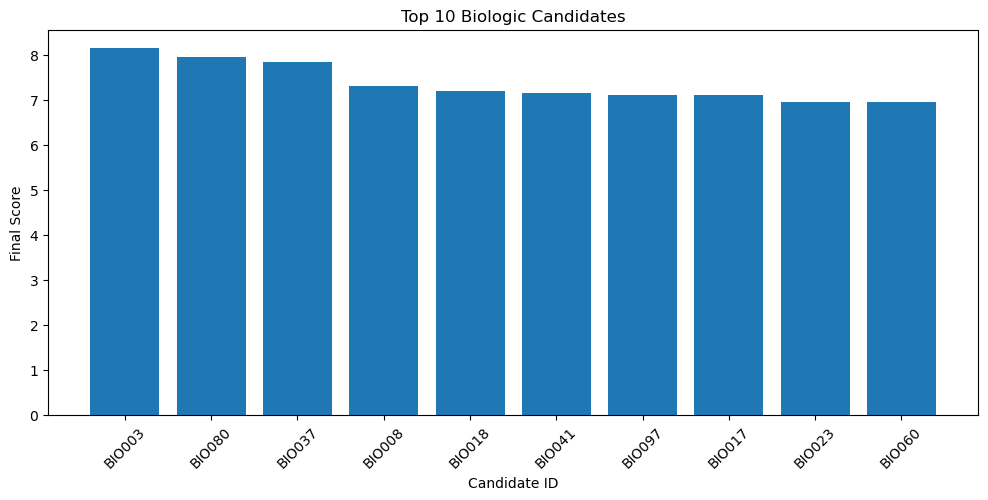

In [11]:
top10 = df.head(10)

plt.figure(figsize=(12,5))
plt.bar(top10["Candidate_ID"], top10["Final_Score"])
plt.title("Top 10 Biologic Candidates")
plt.xlabel("Candidate ID")
plt.ylabel("Final Score")
plt.xticks(rotation=45)
plt.show()

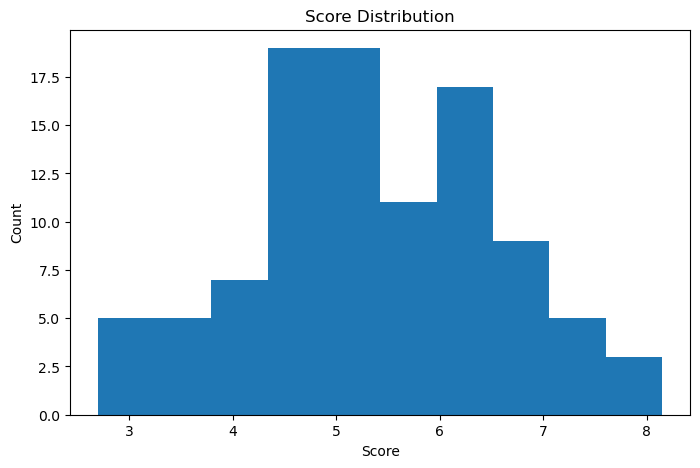

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["Final_Score"], bins=10)
plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

## Key Insights
- Top candidates scored above 8
- Balanced profiles ranked highest
- High toxicity reduced scores significantly
- Useful for early-stage R&D prioritization

In [14]:
!pip install scikit-learn

In [15]:
# If score >= 7.5 then shortlisted
df["Shortlisted"] = (df["Final_Score"] >= 7.5).astype(int)

df[["Candidate_ID","Final_Score","Shortlisted"]].head()

,Candidate_ID,Final_Score,Shortlisted
2,BIO003,8.15,1
79,BIO080,7.95,1
36,BIO037,7.85,1
7,BIO008,7.30,0
17,BIO018,7.20,0


In [16]:
from sklearn.model_selection import train_test_split

X = df[["Stability","Affinity","Solubility","Toxicity","Yield","Immunogenicity"]]
y = df["Shortlisted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.00      0.00      0.00         1

    accuracy                           0.95        20
   macro avg       0.47      0.50      0.49        20
weighted avg       0.90      0.95      0.93        20



C:\Users\zaman asif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zaman asif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\zaman asif\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
2,Solubility,0.208456
4,Yield,0.204169
1,Affinity,0.184613
5,Immunogenicity,0.151746
0,Stability,0.149671
3,Toxicity,0.101344


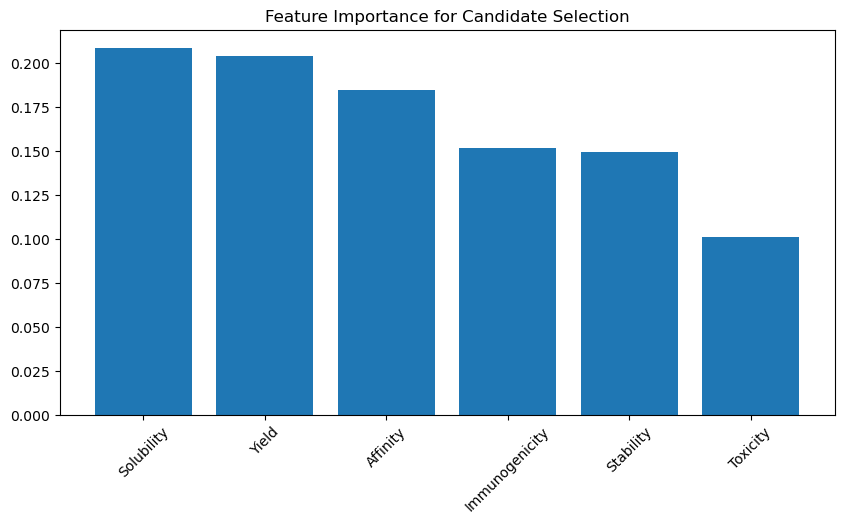

In [20]:
plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance for Candidate Selection")
plt.xticks(rotation=45)
plt.show()